# Retail Sales Analysis (Gold Layer)

This notebook picks up where the SQL warehouse ends. It reads the Gold layer exported by
`python -m pipeline run` (`data/gold/*.csv`) and answers questions that are awkward in SQL or need statistics:

1. **Data-quality audit**: can the Gold layer be trusted?
2. **Revenue trend**: what drove the 2013 jump?
3. **Revenue concentration (Pareto)**: how dependent is the business on a few customers and products?
4. **Category economics**: where is the margin?
5. **Cross-sell**: do bike buyers also buy accessories?
6. **Market performance**: which countries are under-monetised?
7. **RFM segmentation**: who to retain, win back or grow (exported to Power BI)
8. **Cohort retention**: do customers come back?
9. **Demographics with significance testing**: are spend differences real or noise?

Findings are written up for a business audience in [`../INSIGHTS.md`](../INSIGHTS.md).

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from scipy import stats

DATA = Path("../data/gold")
CHARTS = Path("charts")
OUTPUT = Path("output")
CHARTS.mkdir(exist_ok=True)
OUTPUT.mkdir(exist_ok=True)

# Colour-blind-safe palette (validated order) and a shared, quiet chart style
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8593a3"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#EEF1F5",
        "axes.axisbelow": True,
        "axes.titleweight": "semibold",
        "axes.titlesize": 12,
        "font.size": 10,
        "svg.hashsalt": "retail-analysis",
    }
)
pd.options.display.float_format = "{:,.2f}".format
money = mtick.FuncFormatter(lambda v, _: f"${v / 1e6:.1f}M" if abs(v) >= 1e6 else f"${v / 1e3:.0f}K")


def save(fig, name):
    """Save a chart to charts/ with stable metadata so re-runs don't create noisy diffs."""
    fig.tight_layout()
    fig.savefig(CHARTS / name, bbox_inches="tight", metadata={"Software": None})
    plt.show()

## 0. Load the Gold layer

In [2]:
fact = pd.read_csv(DATA / "fact_sales.csv", parse_dates=["order_date", "shipping_date", "due_date"])
# keep_default_na=False keeps the warehouse's literal 'n/a' instead of turning it into NaN
cust = pd.read_csv(
    DATA / "dim_customers.csv",
    keep_default_na=False,
    na_values=[""],
    parse_dates=["birthdate", "create_date"],
)
prod = pd.read_csv(DATA / "dim_products.csv", parse_dates=["start_date"])

sales = fact.merge(prod, on="product_key", how="left").merge(cust, on="customer_key", how="left")
sales["profit"] = sales["sales_amount"] - sales["quantity"] * sales["cost"]
sales["year"] = sales["order_date"].dt.year
AS_OF = fact["order_date"].max()

print(f"fact_sales: {len(fact):,} rows | customers: {len(cust):,} | products: {len(prod):,}")
print(f"order dates: {fact.order_date.min():%Y-%m-%d} to {AS_OF:%Y-%m-%d}")

fact_sales: 60,398 rows | customers: 18,484 | products: 295
order dates: 2010-12-29 to 2014-01-28


## 1. Data-quality audit
The pipeline already gates the warehouse with SQL checks (`sql/quality/`). This is an independent
re-check on the exported files: keys, nulls, duplicates and business rules.

In [3]:
checks = {
    "Fact rows with unknown product_key": (~fact.product_key.isin(prod.product_key)).sum(),
    "Fact rows with unknown customer_key": (~fact.customer_key.isin(cust.customer_key)).sum(),
    "Duplicate order lines (order + product)": fact.duplicated(["order_number", "product_key"]).sum(),
    "Rows where sales != quantity x price": (fact.sales_amount != fact.quantity * fact.price).sum(),
    "Rows with ship date before order date": (fact.shipping_date < fact.order_date).sum(),
    "Rows with NULL order_date": fact.order_date.isna().sum(),
    "Customers with unknown country (n/a)": (cust.country == "n/a").sum(),
    "Customers with unknown gender (n/a)": (cust.gender == "n/a").sum(),
    "Products with cost = 0": (prod.cost == 0).sum(),
}
dq = pd.DataFrame.from_dict(checks, orient="index", columns=["count"])
dq["status"] = np.where(dq["count"].eq(0), "PASS", "REVIEW")
dq

,count,status
Fact rows with unknown product_key,0,PASS
Fact rows with unknown customer_key,0,PASS
Duplicate order lines (order + product),0,PASS
Rows where sales != quantity x price,0,PASS
Rows with ship date before order date,0,PASS
Rows with NULL order_date,19,REVIEW
Customers with unknown country (n/a),337,REVIEW
Customers with unknown gender (n/a),15,REVIEW
Products with cost = 0,2,REVIEW


**Result:** referential integrity, uniqueness and the `sales = quantity × price` rule all pass. The remaining
items are *known* gaps: 19 sales with an invalid (nulled) order date, 337 customers with no country and 2
component products with zero cost. They are small, but every report labels them "Unknown" rather than dropping them.

## 2. Revenue trend: what drove 2013?

In [4]:
yearly = (
    sales.dropna(subset=["order_date"])
    .groupby("year")
    .agg(
        revenue=("sales_amount", "sum"),
        orders=("order_number", "nunique"),
        customers=("customer_key", "nunique"),
    )
)
yearly["aov"] = yearly.revenue / yearly.orders
yearly["revenue_yoy_%"] = yearly.revenue.pct_change() * 100
yearly.index = yearly.index.astype(int)
yearly

,revenue,orders,customers,aov,revenue_yoy_%
year,,,,,
2010,43419,14,14,"3,101.36",NaN
2011,7075088,2216,2216,"3,192.73","16,194.91"
2012,5842231,3269,3255,"1,787.16",-17.43
2013,16344878,21287,17427,767.83,179.77
2014,45642,871,834,52.40,-99.72


In [5]:
cat_year = sales.pivot_table(index="year", columns="category", values="sales_amount", aggfunc="sum").fillna(0)
cat_year.index = cat_year.index.astype(int)
new_customers = fact.groupby("customer_key").order_date.min().dt.year.value_counts().sort_index()
new_customers.index = new_customers.index.astype(int)
print("New customers acquired per year:")
print(new_customers.to_string())
cat_year

New customers acquired per year:
order_date
2010       14
2011     2216
2012     3225
2013    12521
2014      506


category,Accessories,Bikes,Clothing
year,,,
2010,0.00,"43,419.00",0.00
2011,0.00,"7,075,088.00",0.00
2012,"2,146.00","5,839,443.00",642.00
2013,"667,431.00","15,353,707.00","323,740.00"
2014,"30,332.00",0.00,"15,310.00"


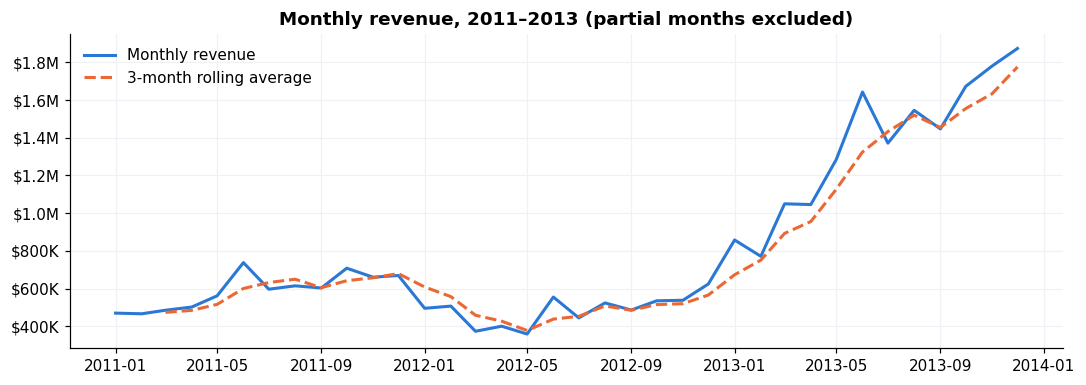

In [6]:
monthly = sales.dropna(subset=["order_date"]).set_index("order_date").sales_amount.resample("MS").sum()
monthly = monthly.loc["2011-01":"2013-12"]  # drop the partial first (Dec 2010) and last (Jan 2014) months

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(monthly.index, monthly.values, color=BLUE, lw=2, label="Monthly revenue")
ax.plot(
    monthly.index, monthly.rolling(3).mean(), color=ORANGE, lw=2, ls="--", label="3-month rolling average"
)
ax.yaxis.set_major_formatter(money)
ax.set_title("Monthly revenue, 2011–2013 (partial months excluded)")
ax.legend(frameon=False, loc="upper left")
save(fig, "01_monthly_revenue.png")

**Insight:** 2013 revenue grew **+180%** (5.8M → 16.3M). Two things happened at once:
* **Customer acquisition exploded**: 12,521 new customers in 2013 vs 3,225 in 2012.
* **Accessories and clothing launched** (mid-2012), which added many small orders. Orders grew about 6.5×,
  but average order value fell from about 1,787 to 768.

The falling AOV is a **mix effect**, not customers spending less on bikes. A dashboard showing only AOV would mislead here.

## 3. Revenue concentration (Pareto)

Top 20% of customers generate 66.4% of revenue
27.9% of customers generate 80% of revenue
35 of 130 products generate 80% of revenue


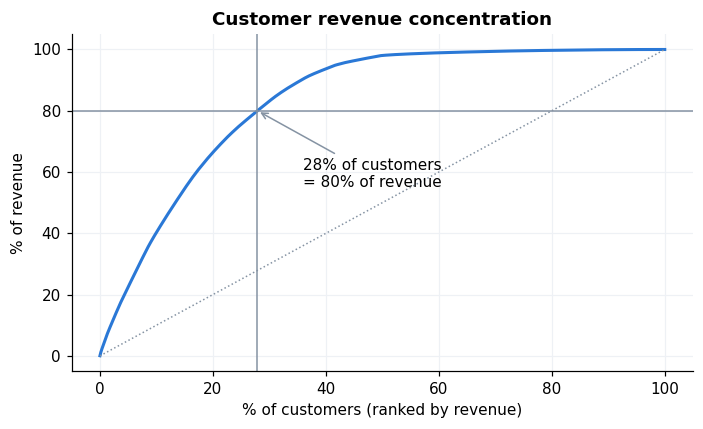

In [7]:
cust_rev = fact.groupby("customer_key").sales_amount.sum().sort_values(ascending=False)
cum_share = cust_rev.cumsum() / cust_rev.sum()
pct_customers = np.arange(1, len(cust_rev) + 1) / len(cust_rev)

top20_share = cum_share.iloc[int(len(cust_rev) * 0.2) - 1]
cust_for_80 = (cum_share <= 0.8).mean()
prod_rev = fact.groupby("product_key").sales_amount.sum().sort_values(ascending=False)
prods_for_80 = ((prod_rev.cumsum() / prod_rev.sum()) <= 0.8).sum() + 1

print(f"Top 20% of customers generate {top20_share:.1%} of revenue")
print(f"{cust_for_80:.1%} of customers generate 80% of revenue")
print(f"{prods_for_80} of {len(prod_rev)} products generate 80% of revenue")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(pct_customers * 100, cum_share * 100, color=BLUE, lw=2)
ax.plot([0, 100], [0, 100], color=GREY, lw=1, ls=":")
ax.axhline(80, color=GREY, lw=1)
ax.axvline(cust_for_80 * 100, color=GREY, lw=1)
ax.annotate(
    f"{cust_for_80:.0%} of customers\n= 80% of revenue",
    (cust_for_80 * 100, 80),
    xytext=(cust_for_80 * 100 + 8, 55),
    arrowprops={"arrowstyle": "->", "color": GREY},
)
ax.set_xlabel("% of customers (ranked by revenue)")
ax.set_ylabel("% of revenue")
ax.set_title("Customer revenue concentration")
save(fig, "02_pareto_customers.png")

**Insight:** revenue is concentrated but not extremely so: **about 28% of customers produce 80% of revenue**, and
**35 of the 130 products that sold** produce 80%. Losing a slice of the top customers would hurt far more than
losing the long tail, which is why the RFM section below focuses on protecting them.

## 4. Category economics: where is the margin?

In [8]:
cat = sales.groupby("category").agg(
    revenue=("sales_amount", "sum"), profit=("profit", "sum"), units=("quantity", "sum")
)
cat["margin_%"] = cat.profit / cat.revenue * 100
cat["revenue_share_%"] = cat.revenue / cat.revenue.sum() * 100
cat["profit_share_%"] = cat.profit / cat.profit.sum() * 100
cat.sort_values("revenue", ascending=False)

,revenue,profit,units,margin_%,revenue_share_%,profit_share_%
category,,,,,,
Bikes,28316272,11109565,15205,39.23,96.46,95.07
Accessories,700262,439510,36112,62.76,2.39,3.76
Clothing,339716,136682,9106,40.23,1.16,1.17


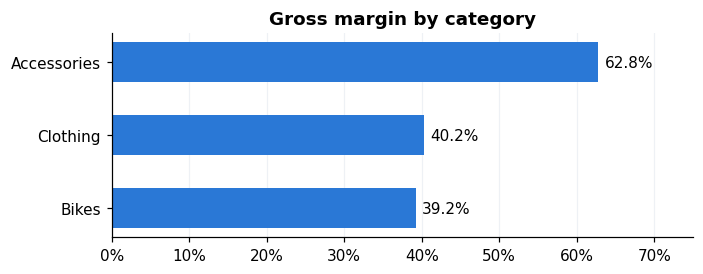

In [9]:
by_margin = cat.sort_values("margin_%")
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(by_margin.index, by_margin["margin_%"], color=BLUE, height=0.55)
for y, v in enumerate(by_margin["margin_%"]):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center")
ax.set_xlim(0, 75)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gross margin by category")
ax.grid(axis="y", visible=False)
save(fig, "03_margin_by_category.png")

**Insight:** Bikes are **96.5% of revenue** at a 39% margin. Accessories are only 2.4% of revenue but earn a
**62.8% margin**, the highest in the catalogue, so every extra accessory is worth disproportionately more profit per dollar.

## 5. Cross-sell: do bike buyers also buy accessories?

In [10]:
basket = sales.groupby("customer_key").category.agg(lambda s: set(s.dropna()))
bike_buyers = basket.apply(lambda s: "Bikes" in s)
acc_buyers = basket.apply(lambda s: "Accessories" in s)
cloth_buyers = basket.apply(lambda s: "Clothing" in s)

acc_attach = (bike_buyers & acc_buyers).sum() / bike_buyers.sum()
cloth_attach = (bike_buyers & cloth_buyers).sum() / bike_buyers.sum()
print(f"Customers who bought a bike:            {bike_buyers.sum():,}")
print(f"  ...of whom also bought accessories:   {acc_attach:.1%}")
print(f"  ...of whom also bought clothing:      {cloth_attach:.1%}")
print(f"Customers who never bought a bike:      {(~bike_buyers).sum():,}")

Customers who bought a bike:            9,132
  ...of whom also bought accessories:   71.5%
  ...of whom also bought clothing:      34.7%
Customers who never bought a bike:      9,352


**Insight:** accessory attach is already high among bike buyers, but **9,352 customers (about half the base) have never
bought a bike**. They came in through accessories and clothing in 2013. That group is the clearest **upsell** opportunity:
they already trust the brand, and one bike order is worth about 40× an average accessory order.

## 6. Market performance: revenue per customer by country

In [11]:
mkt = sales.groupby("country").agg(
    revenue=("sales_amount", "sum"), customers=("customer_key", "nunique"), orders=("order_number", "nunique")
)
mkt["revenue_per_customer"] = mkt.revenue / mkt.customers
mkt["orders_per_customer"] = mkt.orders / mkt.customers
mkt["aov"] = mkt.revenue / mkt.orders
mkt = mkt.drop(index="n/a").sort_values("revenue_per_customer", ascending=False)
mkt

,revenue,customers,orders,revenue_per_customer,orders_per_customer,aov
country,,,,,,
Australia,9060172,3591,6718,"2,523.02",1.87,"1,348.64"
United Kingdom,3391376,1913,3031,"1,772.81",1.58,"1,118.90"
Germany,2894066,1780,2484,"1,625.88",1.40,"1,165.08"
France,2643751,1810,2484,"1,460.64",1.37,"1,064.31"
Canada,1977738,1571,3375,"1,258.90",2.15,586.00
United States,9162327,7482,9230,"1,224.58",1.23,992.67


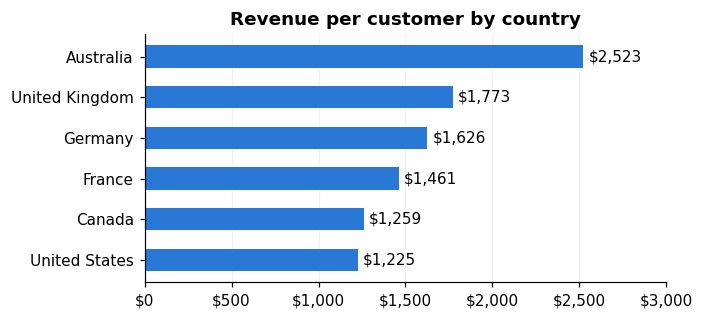

In [12]:
by_value = mkt.sort_values("revenue_per_customer")
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.barh(by_value.index, by_value.revenue_per_customer, color=BLUE, height=0.55)
for y, v in enumerate(by_value.revenue_per_customer):
    ax.text(v + 30, y, f"${v:,.0f}", va="center")
ax.set_xlim(0, 3000)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Revenue per customer by country")
ax.grid(axis="y", visible=False)
save(fig, "04_revenue_per_customer_country.png")

**Insight:** the **US has 2× Australia's customers but the same revenue**: an Australian customer is worth about $2,523,
a US customer about $1,225. The US is under-monetised, not under-penetrated. Canada has the lowest order value but the
most orders per customer, so it behaves like a loyal accessories market.

## 7. RFM segmentation
**R**ecency (days since last order), **F**requency (number of orders) and **M**onetary (total spend), each scored 1–5.
The snapshot date is the day after the last order in the data (2014-01-29), not today, because the data ends in 2014.

In [13]:
snapshot = AS_OF + pd.Timedelta(days=1)
rfm = (
    fact.dropna(subset=["order_date"])
    .groupby("customer_key")
    .agg(
        last_order=("order_date", "max"),
        frequency=("order_number", "nunique"),
        monetary=("sales_amount", "sum"),
    )
)
rfm["recency_days"] = (snapshot - rfm.last_order).dt.days

# Quintiles for R and M. F uses fixed bins because 63% of customers have exactly one order,
# so quintiles on F would split identical customers into different scores.
rfm["R"] = pd.qcut(rfm.recency_days, 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm.monetary.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["F"] = pd.cut(rfm.frequency, bins=[0, 1, 2, 3, np.inf], labels=[1, 3, 4, 5]).astype(int)


def rfm_segment(row):
    if row.R >= 4 and row.F >= 4 and row.M >= 4:
        return "Champions"
    if row.F >= 4 and row.M >= 3:
        return "Loyal"
    if row.R >= 4 and row.F == 1:
        return "New Customers"
    if row.R >= 3 and row.F >= 3:
        return "Potential Loyalists"
    if row.R <= 2 and row.M >= 4:
        return "At Risk (high value)"
    if row.R <= 2:
        return "Hibernating"
    return "Needs Attention"


rfm["rfm_segment"] = rfm.apply(rfm_segment, axis=1)
seg = rfm.groupby("rfm_segment").agg(
    customers=("monetary", "size"),
    revenue=("monetary", "sum"),
    avg_recency_days=("recency_days", "mean"),
    avg_orders=("frequency", "mean"),
    avg_spend=("monetary", "mean"),
)
seg["customer_%"] = seg.customers / seg.customers.sum() * 100
seg["revenue_%"] = seg.revenue / seg.revenue.sum() * 100
seg = seg.sort_values("revenue", ascending=False)
seg

,customers,revenue,avg_recency_days,avg_orders,avg_spend,customer_%,revenue_%
rfm_segment,,,,,,,
At Risk (high value),2888,9615301,369.23,1.56,"3,329.40",15.63,32.76
Potential Loyalists,3593,9281371,105.55,2.01,"2,583.18",19.44,31.62
Champions,541,3495629,76.22,3.55,"6,461.42",2.93,11.91
Loyal,821,3130456,143.19,3.73,"3,812.98",4.44,10.67
New Customers,4148,2246696,72.14,1.00,541.63,22.44,7.65
Needs Attention,2186,848460,169.61,1.00,388.13,11.83,2.89
Hibernating,4305,733345,288.83,1.07,170.35,23.29,2.50


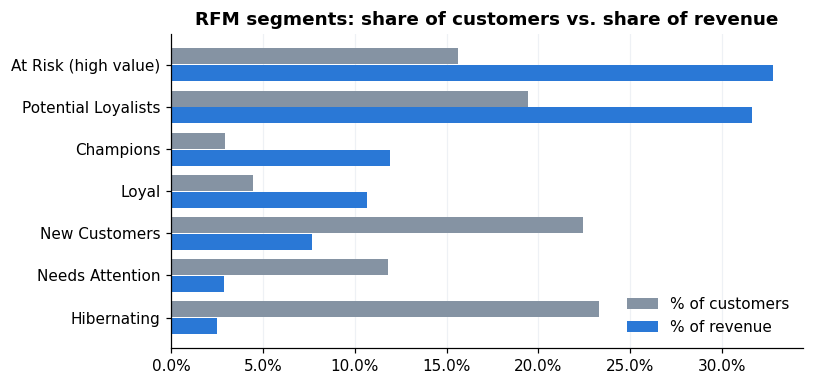

In [14]:
by_revenue = seg.sort_values("revenue_%")
y = np.arange(len(by_revenue))
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(y + 0.2, by_revenue["customer_%"], height=0.38, color=GREY, label="% of customers")
ax.barh(y - 0.2, by_revenue["revenue_%"], height=0.38, color=BLUE, label="% of revenue")
ax.set_yticks(y, by_revenue.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
ax.set_title("RFM segments: share of customers vs. share of revenue")
save(fig, "05_rfm_segments.png")

In [15]:
# Export for Power BI: merged into dim_customers on customer_key
rfm_out = rfm.reset_index()[
    ["customer_key", "recency_days", "frequency", "monetary", "R", "F", "M", "rfm_segment"]
]
rfm_out["rfm_score"] = rfm_out.R.astype(str) + rfm_out.F.astype(str) + rfm_out.M.astype(str)
rfm_out.to_csv(OUTPUT / "rfm_segments.csv", index=False, lineterminator="\n")
print(f"Saved {len(rfm_out):,} rows -> output/rfm_segments.csv")

Saved 18,482 rows -> output/rfm_segments.csv


**Insight:**
* **Champions** are only about 3% of customers but about 12% of revenue (average spend about $6.5K, 6× the typical customer).
* **At Risk (high value)** is the single biggest revenue block: about 2,900 customers, **about 33% of all revenue**, last
  order on average a year ago. These are mostly 2011–2012 bike buyers who never came back, so they are the most urgent win-back target.
* **New Customers** (about 22% of the base) bought once, recently and cheaply (about $540). The job there is a second order.

## 8. Cohort retention
Customers grouped by the quarter of their first order. Each cell shows the % of that cohort who ordered again
*n* quarters later. Quarters after 2013-Q4 are blank because the data ends in January 2014.

In [16]:
orders = fact.dropna(subset=["order_date"])[["customer_key", "order_date"]].copy()
orders["order_q"] = orders.order_date.dt.to_period("Q")
orders["cohort_q"] = orders.groupby("customer_key").order_q.transform("min")
orders["q_index"] = (orders.order_q - orders.cohort_q).apply(lambda offset: offset.n)
cohort = orders.groupby(["cohort_q", "q_index"]).customer_key.nunique().unstack(fill_value=0)
retention = cohort.div(cohort[0], axis=0) * 100

last_full_quarter = pd.Period("2013Q4")
for cohort_q in retention.index:
    for q_index in retention.columns:
        if cohort_q + q_index > last_full_quarter:
            retention.loc[cohort_q, q_index] = np.nan
retention = retention.loc["2011Q1":"2013Q3"]  # cohorts with at least one full following quarter
retention.iloc[:, :9].round(1)

q_index,0,1,2,3,4,5,6,7,8
cohort_q,,,,,,,,,
2011Q1,100.00,0.00,0.00,0.00,0.00,0.00,0.00,1.80,15.30
2011Q2,100.00,0.00,0.00,0.00,0.00,0.00,1.80,25.70,19.30
2011Q3,100.00,0.00,0.00,0.00,0.00,1.60,30.60,26.30,25.10
2011Q4,100.00,0.00,0.00,0.00,0.50,25.30,26.00,36.70,24.90
2012Q1,100.00,0.00,0.00,0.40,10.90,30.50,27.80,35.40,NaN
2012Q2,100.00,0.00,0.40,9.30,31.00,24.60,44.10,NaN,NaN
2012Q3,100.00,0.50,18.90,26.30,41.30,26.30,NaN,NaN,NaN
2012Q4,100.00,9.70,17.60,28.10,41.70,NaN,NaN,NaN,NaN
2013Q1,100.00,10.60,10.30,10.90,NaN,NaN,NaN,NaN,NaN


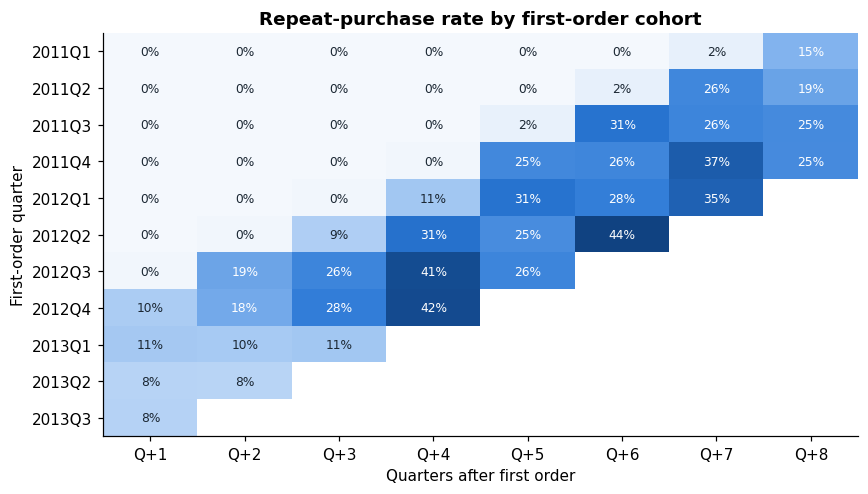

In [17]:
heat = retention.iloc[:, 1:9]
blues = mcolors.LinearSegmentedColormap.from_list("blues", ["#f4f8fd", "#86b6ef", "#2a78d6", "#104281"])
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.imshow(heat.values, cmap=blues, aspect="auto", vmin=0, vmax=max(20, np.nanmax(heat.values)))
ax.set_xticks(range(heat.shape[1]), [f"Q+{i}" for i in heat.columns])
ax.set_yticks(range(heat.shape[0]), [str(i) for i in heat.index])
for (i, j), v in np.ndenumerate(heat.values):
    if not np.isnan(v):
        ax.text(
            j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8, color="white" if v > 12 else "#1B2733"
        )
ax.grid(False)
ax.set_title("Repeat-purchase rate by first-order cohort")
ax.set_xlabel("Quarters after first order")
ax.set_ylabel("First-order quarter")
save(fig, "06_cohort_retention.png")

In [18]:
repeat_rate = (fact.groupby("customer_key").order_number.nunique() > 1).mean()
print(f"Repeat-purchase rate: {repeat_rate:.1%} ({1 - repeat_rate:.1%} of customers bought only once)")

Repeat-purchase rate: 37.1% (62.9% of customers bought only once)


**Insight:** 2011–2012 cohorts (the bike-only era) barely came back until **2013**, when accessories launched and
older cohorts re-activated at 25–45%. That shows up as a bright diagonal band. 2013 cohorts come back at only
about 8–11% the following quarter. Overall **63% of customers bought only once**, so a post-purchase journey
(accessories and servicing 1–2 quarters after a bike) is the biggest retention lever.

## 9. Demographics: real differences or noise?
Welch's t-test (unequal variances) on total spend per customer, with Cohen's d as the effect size.
Ages are measured at the customer's first order.

In [19]:
per_customer = sales.groupby("customer_key").agg(
    spend=("sales_amount", "sum"),
    gender=("gender", "first"),
    marital=("marital_status", "first"),
    birthdate=("birthdate", "first"),
    first_order=("order_date", "min"),
)


def compare(column, group_a, group_b):
    a = per_customer.loc[per_customer[column] == group_a, "spend"]
    b = per_customer.loc[per_customer[column] == group_b, "spend"]
    _, p_value = stats.ttest_ind(a, b, equal_var=False)
    cohens_d = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)
    return {
        "group A": group_a,
        "mean A": a.mean(),
        "group B": group_b,
        "mean B": b.mean(),
        "difference %": (a.mean() / b.mean() - 1) * 100,
        "p-value": p_value,
        "Cohen's d": cohens_d,
    }


pd.DataFrame([compare("gender", "Female", "Male"), compare("marital", "Single", "Married")])

,group A,mean A,group B,mean B,difference %,p-value,Cohen's d
0,Female,"1,621.84",Male,"1,554.69",4.32,0.03,0.03
1,Single,"1,672.40",Married,"1,516.93",10.25,0.00,0.07


In [20]:
age_at_first_order = (per_customer.first_order - per_customer.birthdate).dt.days / 365.25
print(
    f"Age at first order: min {age_at_first_order.min():.0f}, median {age_at_first_order.median():.0f}, "
    f"max {age_at_first_order.max():.0f}"
)

Age at first order: min 25, median 42, max 98


**Insight:**
* Single customers spend about 10% more than married ones. The difference is statistically significant (p < 0.001) but the effect size is small.
* Women spend about 4% more than men. With 18K customers that is significant at p ≈ 0.03, but the effect size is negligible
  (d ≈ 0.03), so gender is **not a basis for targeting**.
* Customers were 25 to 98 at their first order (median 42; the oldest are the 15 pre-1924 birthdates flagged by the
  quality checks). Age only makes sense measured at a fixed point in time, which is why the warehouse reports measure
  age at the last order date rather than today.

## Summary

| # | Finding | Recommended action |
|---|---|---|
| 1 | 2013 growth (+180%) came from new-customer acquisition and the accessories launch; AOV fell only because of mix | Report AOV **by category** so the mix shift isn't misread as weaker demand |
| 2 | Accessories earn a 62.8% margin vs 39% on bikes | Bundle accessories with every bike order; track attach rate as a KPI |
| 3 | About 9.4K customers never bought a bike | Targeted bike upsell to accessory-only buyers |
| 4 | US revenue per customer is half of Australia's | Review US pricing and assortment; push higher-tier bikes |
| 5 | 63% of customers are one-time buyers | Post-purchase journey 1–2 quarters after a bike sale |
| 6 | High-value customers going quiet (RFM "At Risk") hold a third of revenue | Win-back offers prioritised by monetary value |